In [3]:
#Carregando bibliotecas e datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

users = pd.read_csv(
    "../data/processed/users_clean.csv"
)

user_plan = pd.read_csv(
    "../data/processed/user_plan_clean.csv",
    parse_dates=["data_inicio"]
)

user_app = pd.read_csv(
    "../data/processed/user_app_clean.csv",
    parse_dates=["checkin"]
)

activities = pd.read_csv(
    "../data/processed/activities_clean.csv",
    parse_dates=["date"]
)

weekly_visits = pd.read_csv(
    "../data/processed/weekly_visits_clean.csv"
)

challenges = pd.read_csv(
    "../data/processed/challenges_clean.csv",
    parse_dates=["data_inicio", "data_fim"]
)

desafio_usuario = pd.read_csv(
    "../data/processed/desafio_usuario_clean.csv",
    parse_dates=["data_desafio"]
)

In [4]:
#Criando dicionário dos datasets
datasets = {
    'users': users,
    'user_plan': user_plan,
    'user_app': user_app,
    'activities': activities,
    'weekly_visits': weekly_visits,
    'challenges': challenges,
    'desafio_usuario': desafio_usuario
}

Hipótese 1: *Desafios aumentam engajamento:*

    1. Usuários que participam de desafios apresentam maior nível de atividade física do que usuários que não participam.

        Métricas associadas:
            Média de steps por usuário;
            Média de calories_burned;
            Número de atividades registradas.

In [10]:
#Hipótese 1:

##Será usado como unidade de análise o usuário em si, e não a linha de atividade

###Agregando comportamento por usuário
df_user = activities.groupby('user_id').agg({
   'steps':'mean',
   'calories_burned':'mean',
   'activity_id':'count' 
}).reset_index()

###Renomeando as colunas
df_user.rename(columns={
    'steps':'steps_mean',
    'calories_burned':'calories_mean',
    'activity_id':'n_activities'
}, inplace=True)

In [12]:
#Adicionando a variável de participação
participants = desafio_usuario['user_id'].unique()

users['participa'] = users['user_id'].isin(participants)

#Dando Merge
df_user = df_user.merge(
    users[['user_id', 'participa', 'age_group', 'gender', 'distance_to_gym']],
    on='user_id'
)

In [16]:
#Contagem do grupo de participantes
df_user['participa'].value_counts()

participa
False    600
True     400
Name: count, dtype: int64

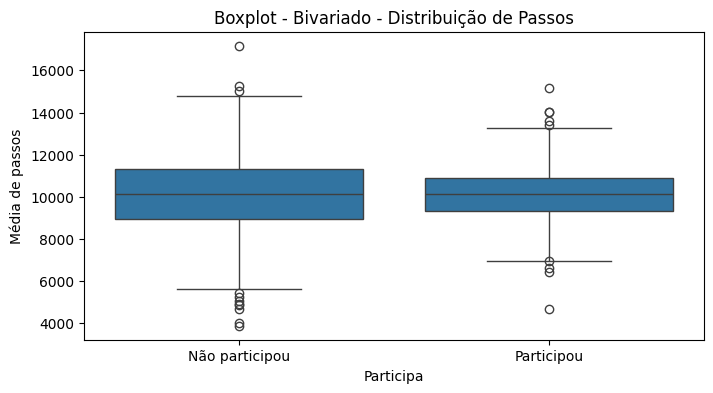

In [14]:
#Entendendo a distribuição dos valores
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

plt.figure(figsize=(8,4))

sns.boxplot(data=df_user,
    x='participa',
    y='steps_mean'
)
plt.xlabel('Participa')
plt.ylabel('Média de passos')
plt.xticks([0,1], ['Não participou', 'Participou'])

plt.title('Boxplot - Bivariado - Distribuição de Passos')

file_path = '../outputs/boxplot_bivariado_passos.png'

plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()


Hipótese 2: *Desafios aumentam retenção:*
    Usuários que participam de desafios apresentam maior frequência de uso do aplicativo ao longo do tempo

        Métricas associadas:
            Média de de visitas semanais à academia;
            Número de check-ins no app;
            Número de registros de atividade por usuário.

In [ ]:
#Hipótese 2:

Hipótese 3: *Desafios estimulam mais atividade física:* Usuários que participam de um maior número de desafios apresentam maior nível de engajamento físico.

        Métricas associadas:
            Steps médios por número de desafios;
            Calorias queimadas por número de desafios.

In [ ]:
#Hipótese 3:

Hipótese 4: *Usuários que participam de mais desafios apresentam maior nível de engajamento:*

    A probabilidade de participação em desafios varia de acordo com características do usuário.
        Métricas associadas:
            Taxa de participação por grupo de idade;
            Taxa de participação por gênero;
            Taxa de participação pela distância da acadêmia.

In [ ]:
#Hipótese 4:

Hipótese 5: *Desafios geram mais frequência de uso:*

    O tipo de atividade do desafio influencia a taxa de participação dos usuários.
        Métricas associadas:
            Número de participantes por tipo de atividade;
            Média de participação por desafio.

In [ ]:
#Hipótese 5:

Hipótese 6: Usuários com maior nível de atividade:

    Usuários apresentam maior volume de atividades durante o período de participação em desafios.
        Métricas associadas:
            Número de atividades durante período do desafio.

In [ ]:
#Hipótese 6: